# Diabetes Prediction Model

---
##Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Data Loading & Exploration

# ── Load dataset

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

col_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(url, names=col_names)
print('✅ Dataset loaded successfully!')

✅ Dataset loaded successfully!


# ── First few rows

In [3]:
print('📌 First 5 rows:')
df.head()

📌 First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# ── Dataset shape

In [4]:
print(f'📐 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

📐 Dataset Shape: 768 rows × 9 columns


# ── Missing values

In [6]:
print('🔍 Missing Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

🔍 Missing Values per Column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


# ── Basic statistics

In [7]:
print('📊 Basic Statistics:')
df.describe()

📊 Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# ── Data types & info

In [8]:
print('🗂 Dataset Info:')
df.info()

🗂 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# ── Class distribution

In [9]:
print('🎯 Target Class Distribution:')
print(df['Outcome'].value_counts())
print(f'\nDiabetes Positive: {df["Outcome"].sum()} ({df["Outcome"].mean()*100:.1f}%)')
print(f'Diabetes Negative: {(df["Outcome"]==0).sum()} ({(1-df["Outcome"].mean())*100:.1f}%)')

🎯 Target Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes Positive: 268 (34.9%)
Diabetes Negative: 500 (65.1%)


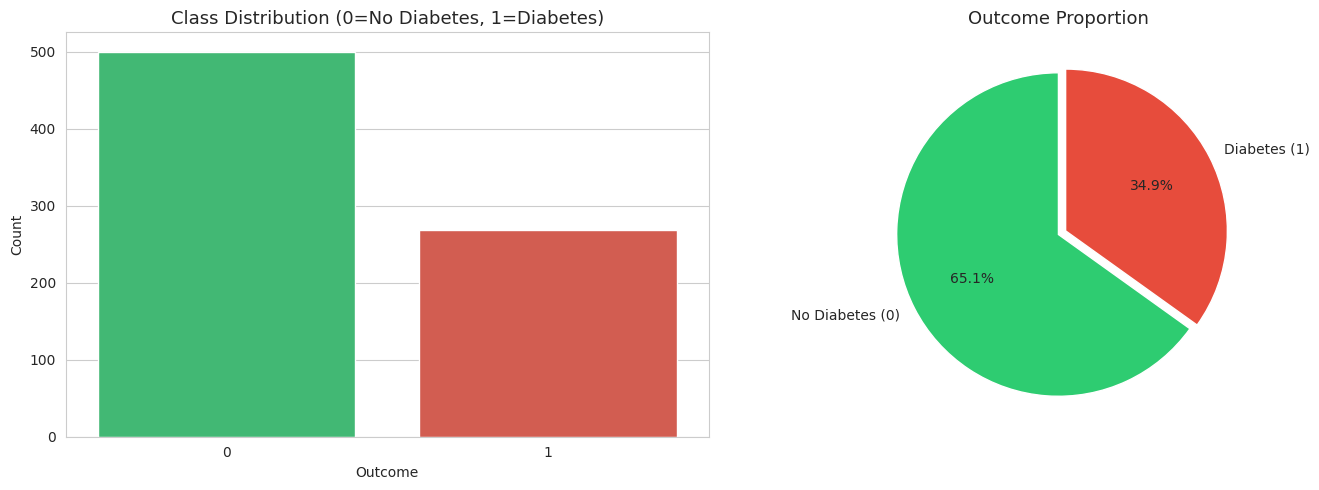

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='Outcome', data=df, palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Class Distribution (0=No Diabetes, 1=Diabetes)', fontsize=13)
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    df['Outcome'].value_counts(),
    labels=['No Diabetes (0)', 'Diabetes (1)'],
    colors=['#2ecc71','#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Outcome Proportion', fontsize=13)

plt.tight_layout()
plt.show()

# ── Feature distributions

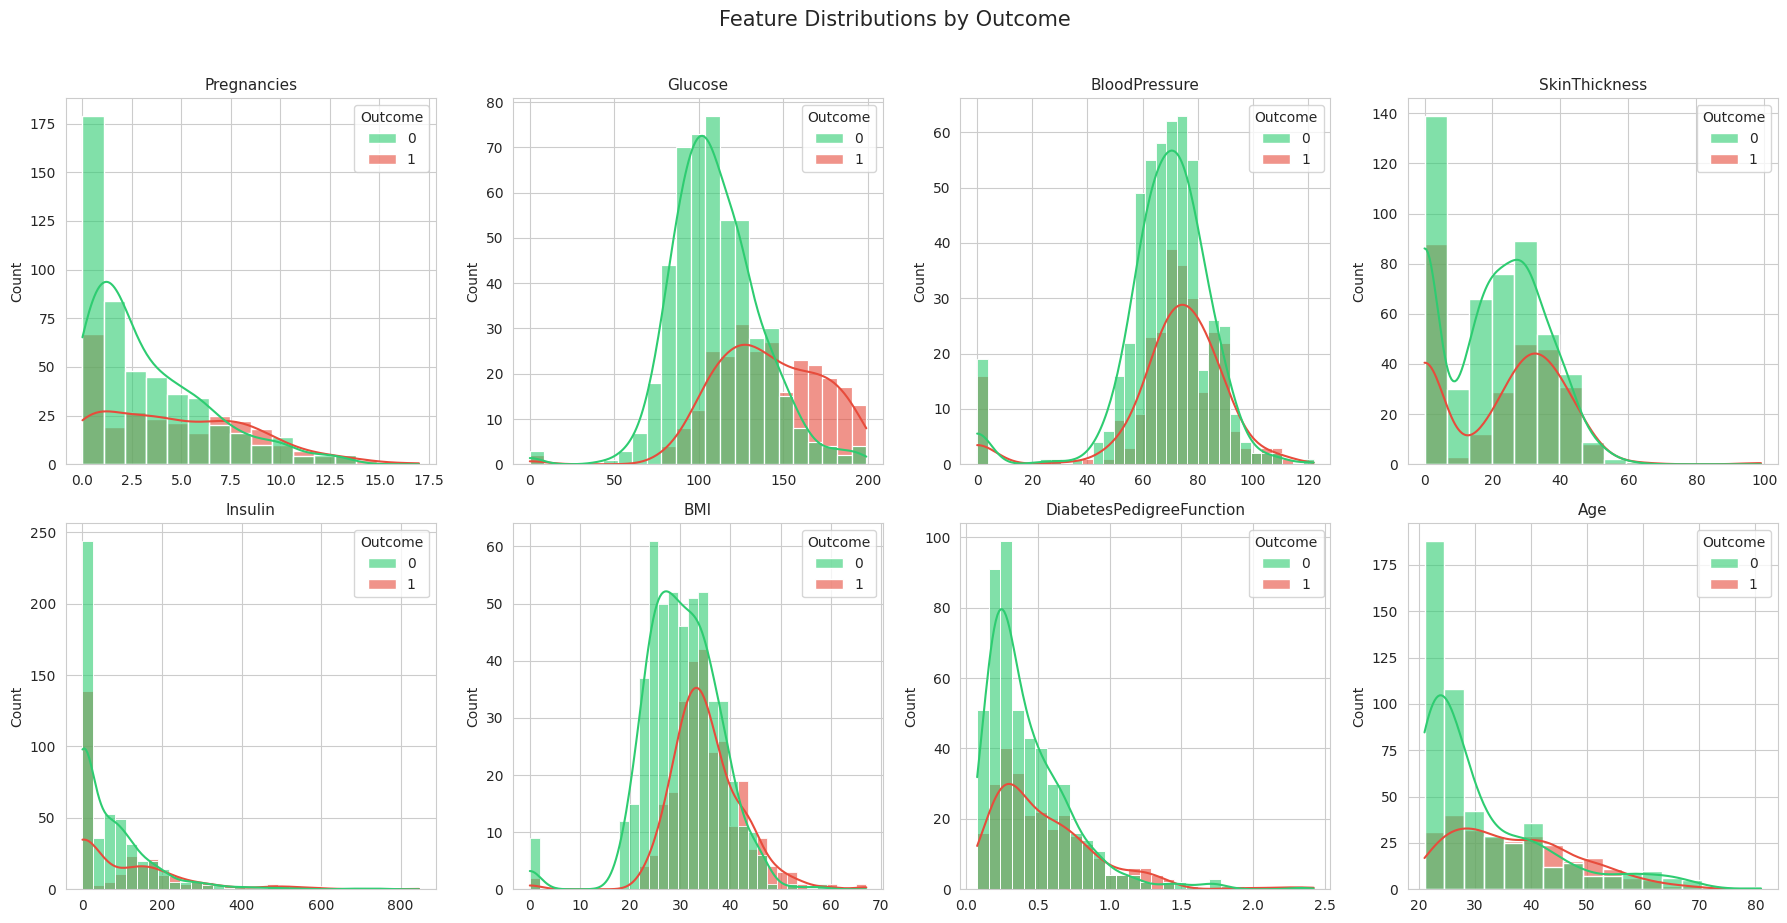

In [11]:
features = df.columns[:-1].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(data=df, x=feat, hue='Outcome', kde=True,
                 palette=['#2ecc71','#e74c3c'], ax=axes[i], alpha=0.6)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Outcome', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ── Correlation heatmap

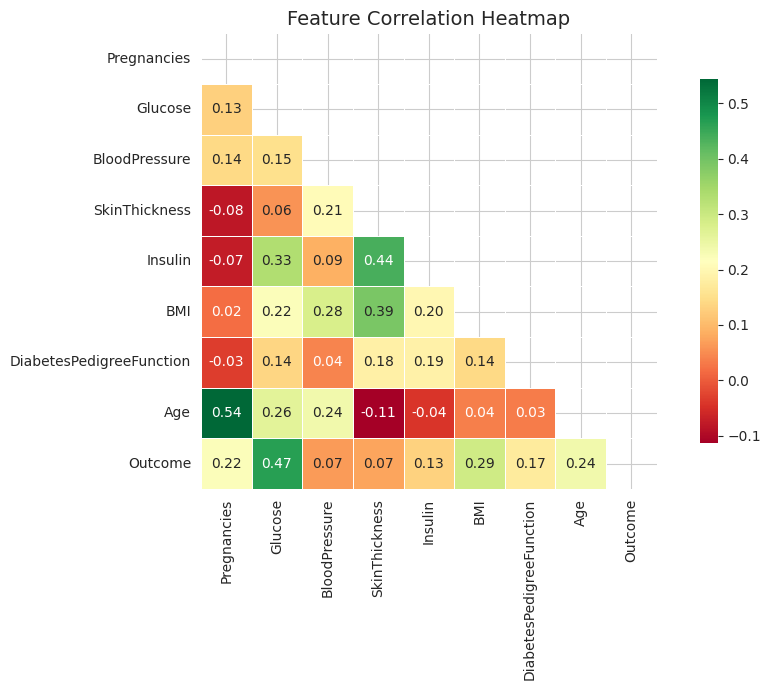

In [12]:
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# ── Zero-value check (biologically implausible zeros)

In [14]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('⚠️  Zero values in biologically implausible columns (treated as missing):')
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    print(f'  {col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)')

⚠️  Zero values in biologically implausible columns (treated as missing):
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


---
##Data Preprocessing

# ── Replace biologically implausible zeros with column median

In [15]:
df_clean = df.copy()

for col in zero_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print('✅ Zeros replaced with column medians for:', zero_cols)
df_clean.describe()

✅ Zeros replaced with column medians for: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# ── Separate features (X) and target (y)

In [23]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f'✅ Features (X) shape : {X.shape}')
print(f'✅ Target  (y) shape  : {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')

✅ Features (X) shape : (768, 8)
✅ Target  (y) shape  : (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


# ── Train / Test Split (80% / 20%)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'✅ Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'✅ Testing set   : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)')

✅ Training set  : 614 samples (80%)
✅ Testing set   : 154 samples  (20%)


# ── Feature Scaling (StandardScaler)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # transform test (no fit!)

print('✅ Feature scaling applied (StandardScaler)')
print(f'  Mean of scaled train: {X_train_scaled.mean():.4f}  (≈ 0)')
print(f'  Std  of scaled train: {X_train_scaled.std():.4f}  (≈ 1)')

✅ Feature scaling applied (StandardScaler)
  Mean of scaled train: 0.0000  (≈ 0)
  Std  of scaled train: 1.0000  (≈ 1)


# ── Define models

In [26]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7)
}

 # ── Train all models

In [27]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f'✅ {name:25s} — trained!')

✅ Logistic Regression       — trained!
✅ Random Forest             — trained!
✅ SVM                       — trained!
✅ Decision Tree             — trained!
✅ KNN                       — trained!


---
## Model Evaluation & ROC Curves

# ── Evaluate all models

In [29]:
results = []

for name, model in trained_models.items():
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    row = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob)
    }
    results.append(row)

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('📊 Model Evaluation Metrics:')
results_df.style.highlight_max(color='green').format('{:.4f}')

📊 Model Evaluation Metrics:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest,0.7597,0.6809,0.5926,0.6337,0.8200
Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8152
SVM,0.7338,0.6444,0.5370,0.5859,0.7939
Decision Tree,0.7662,0.6452,0.7407,0.6897,0.7799
KNN,0.6948,0.5745,0.5000,0.5347,0.7687


# ── ROC Curve

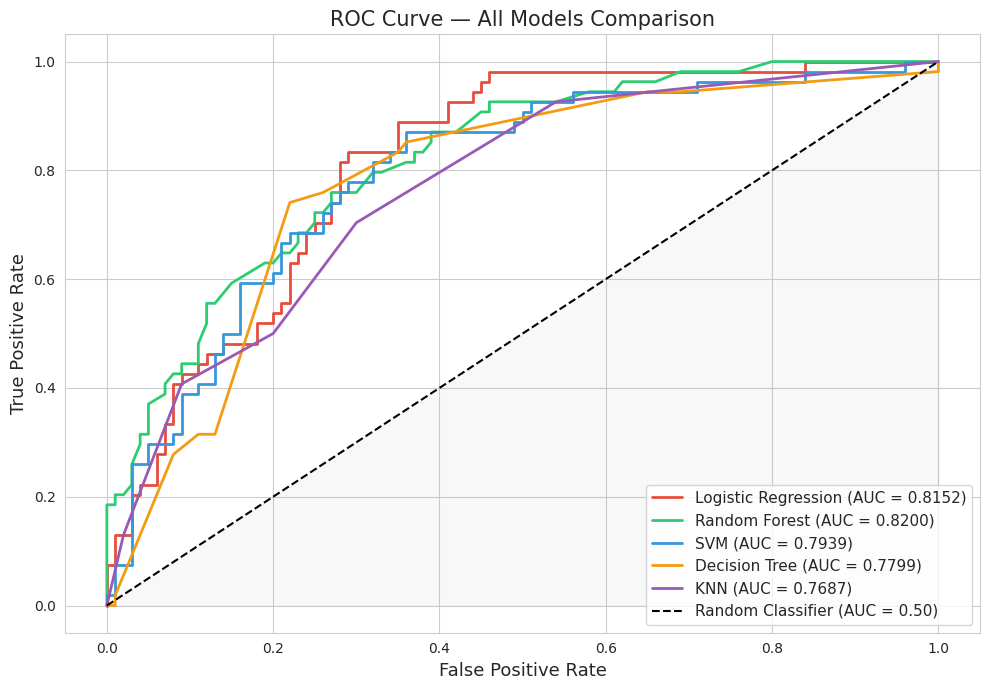

In [31]:
plt.figure(figsize=(10, 7))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for (name, model), color in zip(trained_models.items(), colors):
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score   = roc_auc_score(y_test, y_pred_prob)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — All Models Comparison', fontsize=15)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart

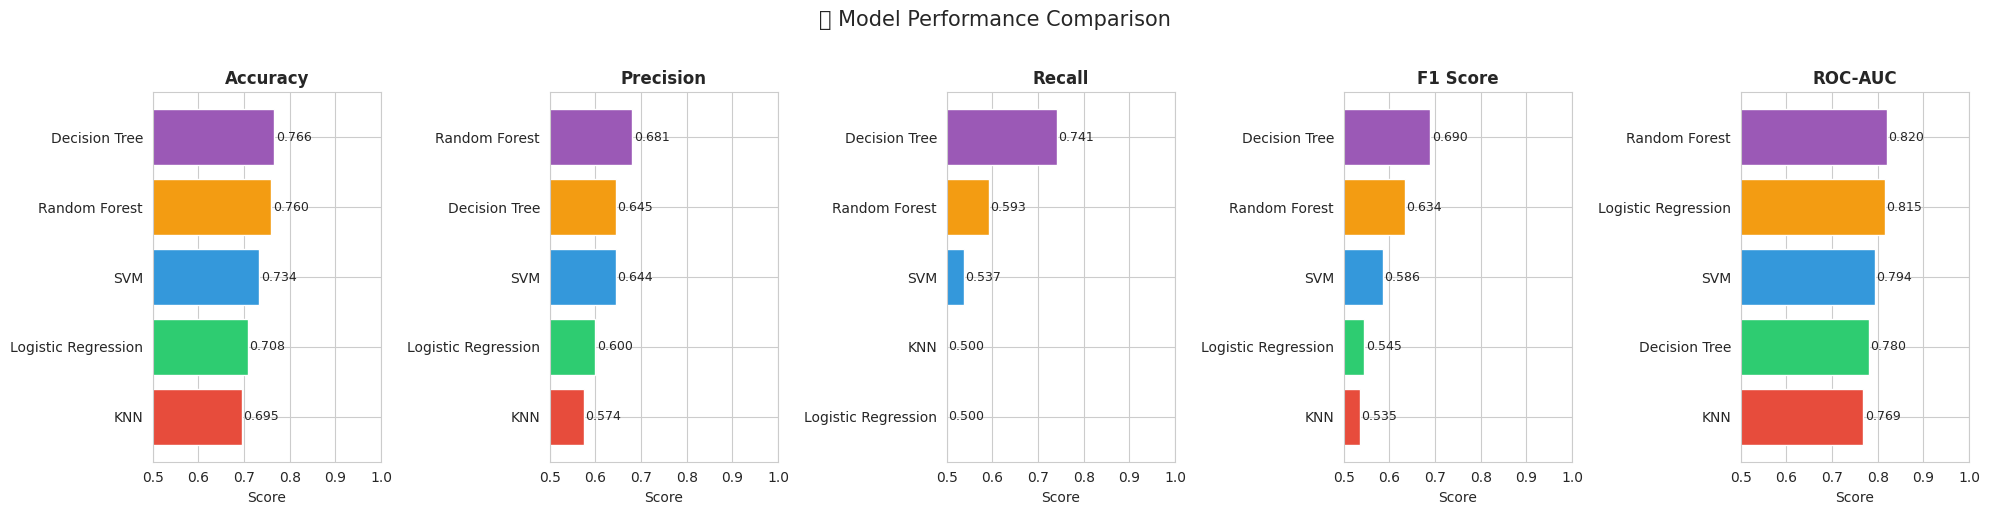

In [33]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5), sharey=False)

palette = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    sorted_df = results_df.sort_values(metric, ascending=True)
    axes[i].barh(sorted_df.index, sorted_df[metric],
                 color=palette, edgecolor='white')
    axes[i].set_xlim(0.5, 1.0)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Score')
    for j, v in enumerate(sorted_df[metric]):
        axes[i].text(v + 0.003, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('📊 Model Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrices for all models

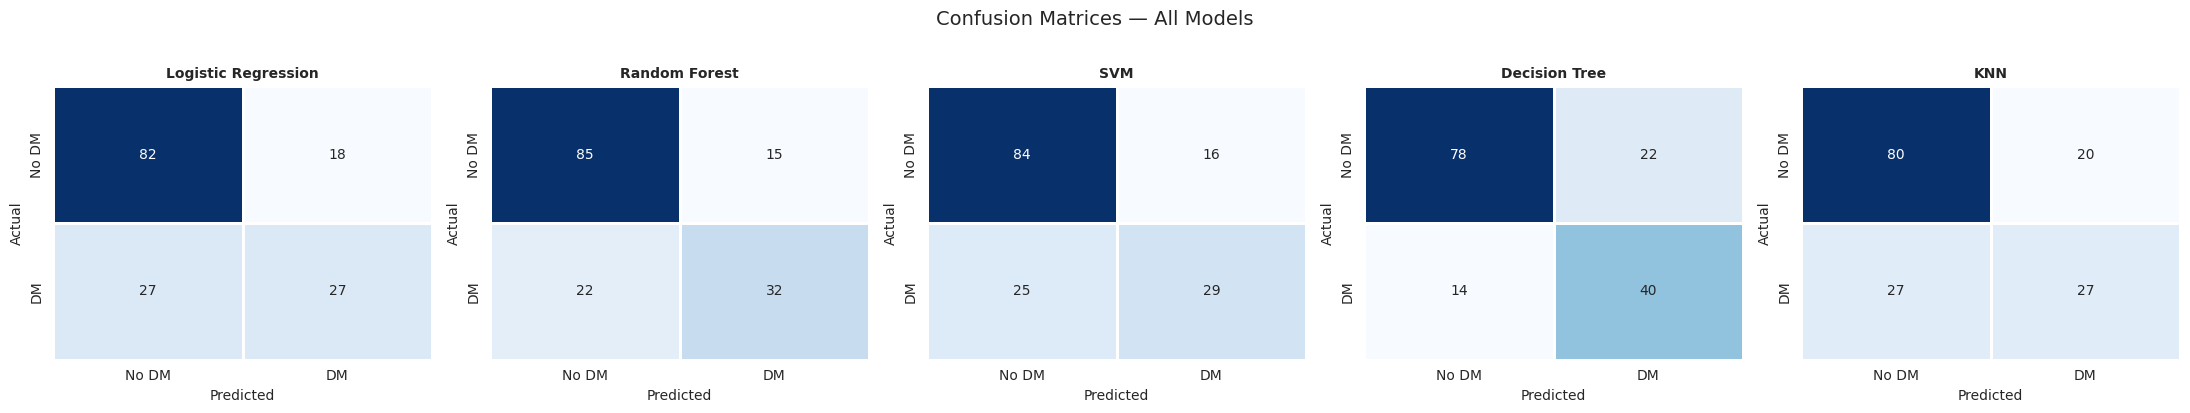

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No DM','DM'], yticklabels=['No DM','DM'],
                cbar=False, linewidths=1)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── best model (by ROC-AUC)

In [36]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test_scaled)

print(f'🏆 Best Model (by ROC-AUC): {best_model_name}')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Diabetes', 'Diabetes']))

🏆 Best Model (by ROC-AUC): Random Forest

📋 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       100
    Diabetes       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



---
## 6️⃣ Best Model Selection & Save

# ── Save best model using joblib

In [38]:
joblib.dump(best_model, 'diabetes_model.pkl')
joblib.dump(scaler,     'diabetes_scaler.pkl')   # save scaler too!

print(f'✅ Best model saved  → diabetes_model.pkl')
print(f'✅ Scaler saved      → diabetes_scaler.pkl')

✅ Best model saved  → diabetes_model.pkl
✅ Scaler saved      → diabetes_scaler.pkl


# ── Summary table

In [ ]:
print('=' * 65)
print('           FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)
print(f'\n🏆 BEST MODEL  : {best_model_name}')
print(f'   ROC-AUC     : {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'   Accuracy    : {results_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'   F1 Score    : {results_df.loc[best_model_name, "F1 Score"]:.4f}')

           FINAL MODEL COMPARISON SUMMARY
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Model                                                                 
Random Forest        0.759740   0.680851  0.592593  0.633663  0.820000
Logistic Regression  0.707792   0.600000  0.500000  0.545455  0.815185
SVM                  0.733766   0.644444  0.537037  0.585859  0.793889
Decision Tree        0.766234   0.645161  0.740741  0.689655  0.779907
KNN                  0.694805   0.574468  0.500000  0.534653  0.768704

🏆 BEST MODEL  : Random Forest
   ROC-AUC     : 0.8200
   Accuracy    : 0.7597
   F1 Score    : 0.6337


# ── Verify: reload and predict

In [40]:
loaded_model  = joblib.load('diabetes_model.pkl')
loaded_scaler = joblib.load('diabetes_scaler.pkl')

In [41]:
# Sample prediction (first test row)
sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)[0]
prob = loaded_model.predict_proba(sample_scaled)[0][1]

print('🔁 Model reload verification:')
print(f'   Sample features : {sample.values.tolist()}')
print(f'   Prediction      : {"Diabetes" if pred == 1 else "No Diabetes"} (class {pred})')
print(f'   Probability     : {prob:.4f}')
print(f'   Actual label    : {y_test.iloc[0]}')
print('\n✅ Model loaded and working correctly!')

🔁 Model reload verification:
   Sample features : [[7.0, 159.0, 64.0, 23.0, 30.5, 27.4, 0.294, 40.0]]
   Prediction      : Diabetes (class 1)
   Probability     : 0.6700
   Actual label    : 0

✅ Model loaded and working correctly!
